
<p aligh="center"> <img src="./images/A2C_network_architectures.png"> </p>
<!-- ![A2C network architectures](./images/A2C_network_architectures.png) -->


Choosing separate, non-sharing architectures for A2C eliminates training instability caused by conflicting gradient scales between the actor and critic [1]. This approach prevents large value function gradients from overpowering policy gradients, removes the need to balance losses with hyperparameters, and allows specialized representations for each task.<details open>
<summary> <b> [1] </b> </summary>
Levine, S. "Sep 11: Actor-Critic Introduction, Lecture 5." In: *CS 294: Deep Reinforcement Learning, Fall 2017*. UC Berkeley, 2017. [Course Link](https://rail.eecs.berkeley.edu/deeprlcourse-fa17/index.html#lectures)
</details>


In [31]:
import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import gymnasium as gym
import matplotlib.pyplot as plt
import pickle
import torch as T
import random
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import torch


seed = 42
T.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

#### Environment Exploration

In [32]:
SEED = seed
env = gym.make("MountainCarContinuous-v0")
obs, _ = env.reset(seed=SEED)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
action_low = env.action_space.low[0]
action_high = env.action_space.high[0]
max_steps = env._max_episode_steps

print(f"State dimension  : {state_dim}")
print(f"Action dimension : {action_dim}")
print(f"Action range     : [{action_low}, {action_high}]")
print(f"Max steps        : {max_steps}")
print(f"Initial state    : {obs}")

State dimension  : 2
Action dimension : 1
Action range     : [-1.0, 1.0]
Max steps        : 999
Initial state    : [-0.4452088  0.       ]


##### Random Agent Rollout

In [33]:
def random_rollout(env, seed=SEED):
    obs, _ = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    terminated, truncated = False, False

    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        steps += 1

    return total_reward, steps

total_reward, steps = random_rollout(env)
print(f"Total reward : {total_reward:.2f}")
print(f"Steps taken  : {steps}")
print(f"Goal reached : {steps < 999}")

Total reward : -33.56
Steps taken  : 999
Goal reached : False


##### REINFORCE IMPLEMENTATION

In [34]:
# Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.SELU(),
            nn.Linear(64, 64),
            nn.SELU(),
            nn.Linear(64, action_dim)
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, x: torch.Tensor):
        mean = torch.tanh(self.model(x))
        std = self.log_std.exp()
        return mean, std

    def act(self, state: torch.Tensor):
        mean, std = self.forward(state)
        pd = T.distributions.Normal(loc=mean, scale=std)
        action = pd.sample()
        log_prob = pd.log_prob(action)
        return action.clamp(-1.0, 1.0), log_prob

In [35]:
# Training function
def train(policy, optimizer, log_probs, rewards, gamma):
    T = len(rewards)
    returns = np.zeros(T, dtype=np.float32)
    future_return = 0.0

    for t in reversed(range(T)):
        future_return = rewards[t] + gamma * future_return
        returns[t] = future_return

    returns = torch.tensor(returns)
    log_probs = torch.stack(log_probs)

    loss = -(log_probs * returns).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


### Training loop

def train_reinforce(env, policy, optimizer, gamma, num_episodes):
    episode_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=SEED + episode)
        log_probs = []
        rewards = []
        terminated, truncated = False, False

        while not (terminated or truncated):
            state_tensor = torch.FloatTensor(state)
            action, log_prob = policy.act(state_tensor)
            action_np = action.detach().numpy()

            state, reward, terminated, truncated, _ = env.step(action_np)
            log_probs.append(log_prob)
            rewards.append(reward)

        train(policy, optimizer, log_probs, rewards, gamma)
        episode_rewards.append(sum(rewards))

        if (episode + 1) % 10 == 0:
            avg = np.mean(episode_rewards[-10:])
            print(f"Episode {episode+1} | Avg Reward (last 10): {avg:.2f}")

    return episode_rewards

Episode 10 | Avg Reward (last 10): -52.39
Episode 20 | Avg Reward (last 10): -52.51
Episode 30 | Avg Reward (last 10): -52.23
Episode 40 | Avg Reward (last 10): -53.38
Episode 50 | Avg Reward (last 10): -53.75
Episode 60 | Avg Reward (last 10): -53.38
Episode 70 | Avg Reward (last 10): -53.08
Episode 80 | Avg Reward (last 10): -53.88
Episode 90 | Avg Reward (last 10): -54.29
Episode 100 | Avg Reward (last 10): -53.97
Episode 110 | Avg Reward (last 10): -52.92
Episode 120 | Avg Reward (last 10): -53.58
Episode 130 | Avg Reward (last 10): -53.10
Episode 140 | Avg Reward (last 10): -52.44
Episode 150 | Avg Reward (last 10): -53.10
Episode 160 | Avg Reward (last 10): -54.21
Episode 170 | Avg Reward (last 10): -54.17
Episode 180 | Avg Reward (last 10): -53.51
Episode 190 | Avg Reward (last 10): -53.17
Episode 200 | Avg Reward (last 10): -53.54
Episode 210 | Avg Reward (last 10): -52.28
Episode 220 | Avg Reward (last 10): -52.97
Episode 230 | Avg Reward (last 10): -53.05
Episode 240 | Avg Re

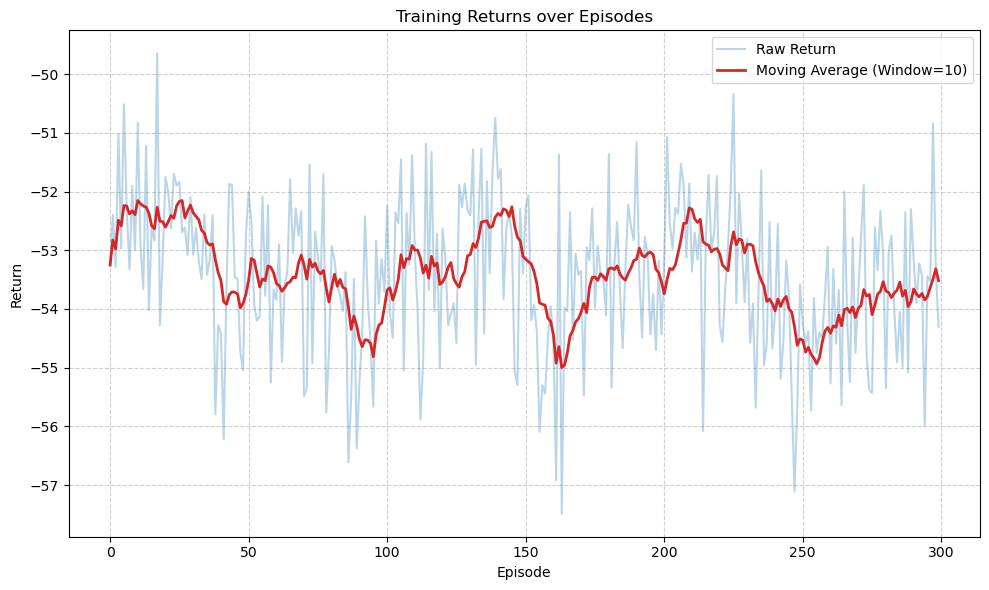

In [36]:
# train_reinforce(env, PolicyNetwork(state_dim, action_dim), optim.Adam(PolicyNetwork(state_dim, action_dim).parameters(), lr=0.001), gamma=0.95, num_episodes=500)

########### TRAINING AND VISUALIZING THE RESULTS

import matplotlib.pyplot as plt
import numpy as np

def plot_returns(rewards, window_size=10):
    # Calculate the moving average
    moving_avg = []
    for i in range(len(rewards)):
        # Use a shrinking window for the early episodes before window_size is reached
        start_idx = max(0, i - window_size + 1)
        moving_avg.append(np.mean(rewards[start_idx : i + 1]))

    # Plotting
    plt.figure(figsize=(10, 6))

    # Plot raw returns with lower opacity (alpha) so it doesn't clutter the graph
    plt.plot(rewards, color='tab:blue', alpha=0.3, label='Raw Return')

    # Plot moving average as a solid line
    plt.plot(moving_avg, color='tab:red', linewidth=2, label=f'Moving Average (Window={window_size})')

    plt.title('Training Returns over Episodes')
    plt.xlabel('Episode')
    plt.ylabel('Return')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    # Show the plot
    plt.show()

# 1. Instantiate the policy network ONCE and save it to a variable
policy = PolicyNetwork(state_dim, action_dim)

# 2. Pass the parameters of THAT EXACT policy to the optimizer
optimizer = optim.Adam(policy.parameters(), lr=0.0001)

# 3. Pass the policy, optimizer, and capture the returned rewards array
episode_rewards = train_reinforce(
    env=env,
    policy=policy,
    optimizer=optimizer,
    gamma=0.95,
    num_episodes=300
)

# 4. Plot the results
plot_returns(episode_rewards, window_size=10)

### A2C IMPLEMENTATION

In [ ]:
### Implementing the actor network, critic networks, Agent class, and a small rollout buffer


class ActorNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, n_actions)
        self.log_std = nn.Linear(fc2_dims, n_actions)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)
        log_std = self.log_std(x)
        log_std = T.clamp(log_std, -20, 2)
        std = T.exp(log_std)
        return mu, std


class CriticNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        value = self.v(x)
        return value


class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.__init__()


class Agent:
    def __init__(self, lr_actor, lr_critic, input_dims, n_actions,
                 gamma=0.99, gae_lambda=0.95, entropy_coeff=0.5,
                 min_entropy_coeff=0.01, entropy_decay=0.9995,
                 layer1_size=256, layer2_size=256):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff
        self.min_entropy_coeff = min_entropy_coeff
        self.entropy_decay = entropy_decay

        self.actor = ActorNetwork(lr_actor, input_dims, layer1_size, layer2_size, n_actions)
        self.critic = CriticNetwork(lr_critic, input_dims, layer1_size, layer2_size)
        self.memory = RolloutBuffer()

    def decay_entropy(self):
        self.entropy_coeff = max(
            self.min_entropy_coeff,
            self.entropy_coeff * self.entropy_decay
        )

    # def choose_action(self, observation):
    #     state = T.tensor(np.array(observation), dtype=T.float32)

    #     mu, std = self.actor(state)
    #     dist = T.distributions.Normal(mu, std)
    #     raw_action = dist.sample()
    #     action = T.tanh(raw_action)

    #     log_prob = dist.log_prob(raw_action).sum()
    #     value = self.critic(state).squeeze()

    #     return action.detach().numpy(), log_prob, value

    def choose_action(self, observation):
        state = T.tensor(np.array(observation), dtype=T.float32)

        mu, std = self.actor(state)
        dist = T.distributions.Normal(mu, std)
        raw_action = dist.sample()
        action = T.tanh(raw_action)

        # Correct log prob: account for tanh squashing
        log_prob = dist.log_prob(raw_action).sum()
        log_prob -= T.log(1 - action**2 + 1e-8).sum()

        value = self.critic(state).squeeze()

        return action.detach().numpy(), log_prob, value


    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)

    def compute_returns_advantages(self, last_state, done):
        last_state = T.tensor(np.array(last_state), dtype=T.float32)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values]

        returns = []
        advantages = []

        gae = 0.0
        values = values + [next_value]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = T.tensor(returns, dtype=T.float32)
        advantages = T.tensor(advantages, dtype=T.float32)

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = T.tensor(np.array(self.memory.states), dtype=T.float32)
        actions = T.tensor(np.array(self.memory.actions), dtype=T.float32)
        # old_log_probs = T.stack(self.memory.log_probs)
        # values = T.stack(self.memory.values).squeeze()

        mu, std = self.actor(states)
        dist = T.distributions.Normal(mu, std)

        raw_actions = T.atanh(T.clamp(actions, -0.999, 0.999))
        log_probs = dist.log_prob(raw_actions).sum(dim=-1)
        log_probs -= T.log(1 - actions**2 + 1e-6).sum(dim=-1)  # tanh correction

        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze(-1) # squeeze last dim only

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor.optimizer.zero_grad()
        self.critic.optimizer.zero_grad()
        loss.backward()
        # Clip gradients to prevent explosion
        nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
        nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
        self.actor.optimizer.step()
        self.critic.optimizer.step()

        self.memory.clear()

In [12]:
def train_agent(lr_actor, lr_critic, gamma, num_episodes=100, n_steps=20, layer1_size=256, layer2_size=256, coeff=0.01):
    env = gym.make('MountainCarContinuous-v0')

    agent = Agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        input_dims=[env.observation_space.shape[0]], # 2
        n_actions=env.action_space.shape[0], # 1
        gamma=gamma,
        layer1_size=layer1_size,
        layer2_size=layer2_size,
        entropy_coeff=coeff,
        min_entropy_coeff=0.01,
        entropy_decay=0.9995
    )

    score_history = []

    for episode in range(num_episodes):
        observation, info = env.reset(seed=seed + episode)
        done = False
        score = 0
        step_count = 0

        while not done:
            action, log_prob, value = agent.choose_action(observation)

            action = np.array(action, dtype=np.float32).reshape((1,))
            observation_, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store_transition(
                state=observation,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value
            )

            score += reward
            step_count += 1
            observation = observation_

            if step_count % n_steps == 0:
                agent.learn(observation, done)

        # agent.decay_entropy()
        score_history.append(score)
        print(
            f'gamma={gamma:.2f} | episode: {episode + 1}/{num_episodes} '
            f'| score: {score:.2f}'
        )

    env.close()
    return score_history


def save_results(results, filename='training_logs.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f'Training logs saved to {filename}')


def plot_all(results, window=10, filename='gamma_comparison_a2c.png'):
    plt.figure(figsize=(12, 6))

    for gamma, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        plt.plot(running_avg, label=f'γ = {gamma}')

    plt.title(f'A2C on MountainCarContinuous — {window}-episode rolling average')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()

def moving_average(x, window=10):
    return np.convolve(x, np.ones(window)/window, mode='valid')


Training with gamma = 0.95
gamma=0.95 | episode: 1/300 | score: -43.34
gamma=0.95 | episode: 2/300 | score: -39.62
gamma=0.95 | episode: 3/300 | score: -36.56
gamma=0.95 | episode: 4/300 | score: -31.74
gamma=0.95 | episode: 5/300 | score: -26.62
gamma=0.95 | episode: 6/300 | score: -24.33
gamma=0.95 | episode: 7/300 | score: -20.60
gamma=0.95 | episode: 8/300 | score: -16.18
gamma=0.95 | episode: 9/300 | score: -14.49
gamma=0.95 | episode: 10/300 | score: -11.68
gamma=0.95 | episode: 11/300 | score: -8.94
gamma=0.95 | episode: 12/300 | score: -7.38
gamma=0.95 | episode: 13/300 | score: -5.83
gamma=0.95 | episode: 14/300 | score: -4.73
gamma=0.95 | episode: 15/300 | score: -3.58
gamma=0.95 | episode: 16/300 | score: -2.95
gamma=0.95 | episode: 17/300 | score: -1.96
gamma=0.95 | episode: 18/300 | score: -1.70
gamma=0.95 | episode: 19/300 | score: -1.27
gamma=0.95 | episode: 20/300 | score: -0.92
gamma=0.95 | episode: 21/300 | score: -0.71
gamma=0.95 | episode: 22/300 | score: -0.53
gam

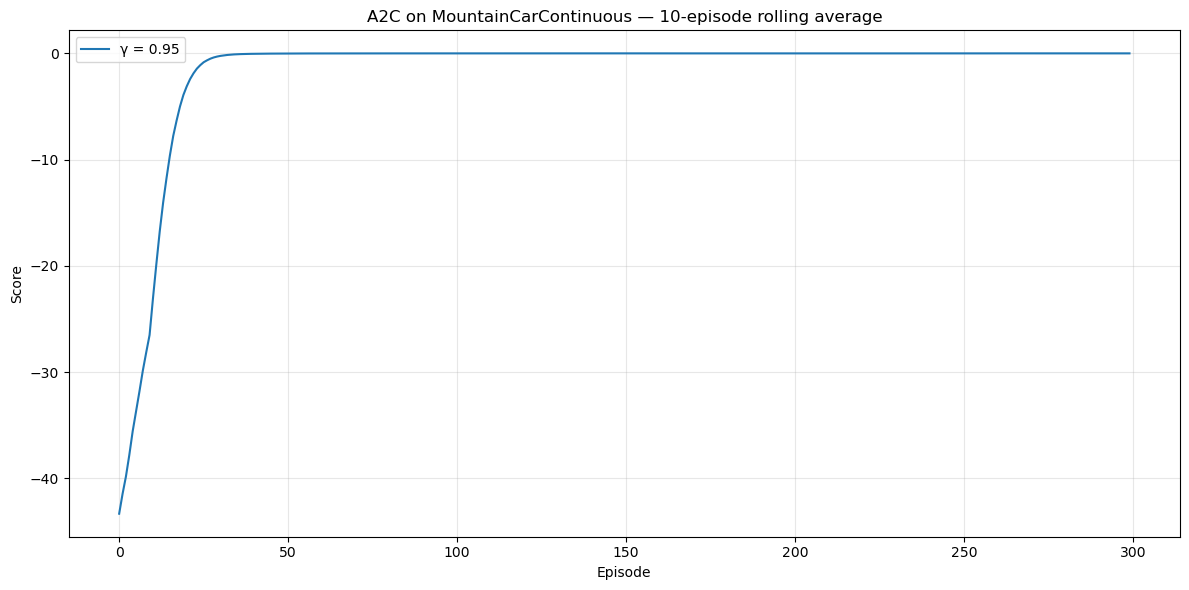

In [11]:
### Main training loop

gammas = [0.95]
num_episodes = 300
lr_actor = 0.00001
lr_critic = 0.00001
n_steps = 10 # rollout buffer update frequency

results = {}

for gamma in gammas:
    print(f'\n{"=" * 50}')
    print(f'Training with gamma = {gamma}')
    print(f'{"=" * 50}')
    results[gamma] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

save_results(results, filename='training_logs_gammas.pkl')
plot_all(results, window=10, filename='_a2c.png')

#### Varrying the Entropy Coefficient to look at how it affect the performance of A2C


Training with coeff=0e+00
gamma=0.95 | episode: 1/300 | score: -19.41
gamma=0.95 | episode: 2/300 | score: -2.81
gamma=0.95 | episode: 3/300 | score: -0.50
gamma=0.95 | episode: 4/300 | score: -0.13
gamma=0.95 | episode: 5/300 | score: -0.10
gamma=0.95 | episode: 6/300 | score: -0.07
gamma=0.95 | episode: 7/300 | score: -0.03
gamma=0.95 | episode: 8/300 | score: -0.02
gamma=0.95 | episode: 9/300 | score: -0.12
gamma=0.95 | episode: 10/300 | score: -0.05
gamma=0.95 | episode: 11/300 | score: -0.07
gamma=0.95 | episode: 12/300 | score: -0.21
gamma=0.95 | episode: 13/300 | score: -0.01
gamma=0.95 | episode: 14/300 | score: -0.37
gamma=0.95 | episode: 15/300 | score: -0.25
gamma=0.95 | episode: 16/300 | score: -0.06
gamma=0.95 | episode: 17/300 | score: -0.03
gamma=0.95 | episode: 18/300 | score: -0.01
gamma=0.95 | episode: 19/300 | score: -0.07
gamma=0.95 | episode: 20/300 | score: -0.03
gamma=0.95 | episode: 21/300 | score: -0.20
gamma=0.95 | episode: 22/300 | score: -0.23
gamma=0.95 | 

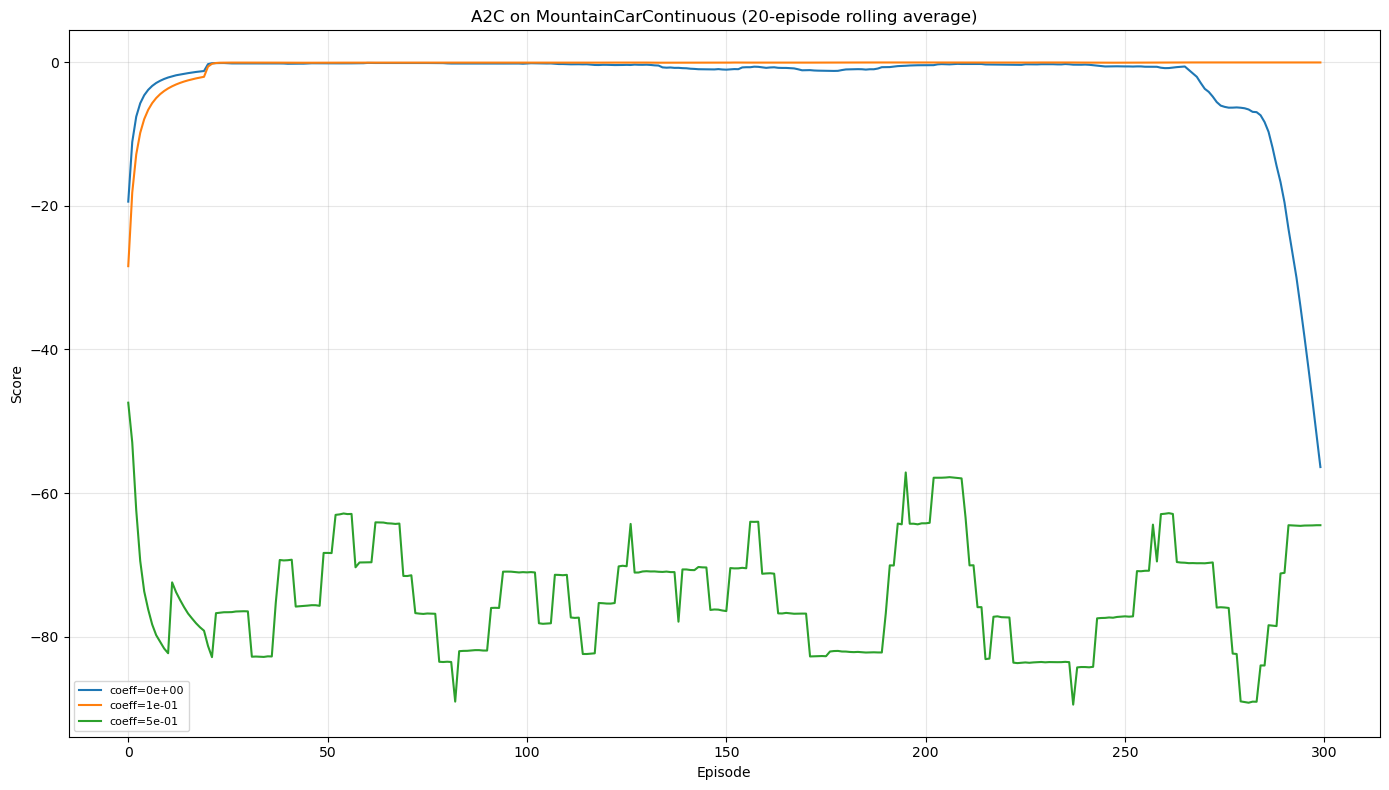

In [16]:
def plot_all_coef(results, window=10, filename='coeff_comparison_a2c.png'):
    """
    results: dict of {entropy_coeff: score_history_list}
    """
    plt.figure(figsize=(14, 8))

    for coeff, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        label = f"coeff={coeff:.0e}"
        plt.plot(running_avg, label=label)

    plt.title(f'A2C on MountainCarContinuous ({window}-episode rolling average)')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    print(f'Plot saved to {filename}')


gamma = 0.95
num_episodes = 300
n_steps = 10

# Fixed learning rates for this experiment
lr_actor = 0.0001
lr_critic = 0.0001

# Entropy coefficient combinations to test
coeff_combinations = [
    0.0,     # no entropy regularization
    # 0.01,   # very low entropy -> the effect of this is already known from the above result
    0.1,
    0.5,
]

results = {}

for coeff in coeff_combinations:
    label = f"coeff={coeff:.0e}"
    print(f'\n{"=" * 50}')
    print(f'Training with {label}')
    print(f'{"=" * 50}')

    results[coeff] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=coeff,
    )

save_results(results, filename='training_logs_coeff.pkl')
plot_all_coef(results, window=20, filename='coeff_comparison_a2c.png')

Plot saved to coeff_comparison_a2c.png


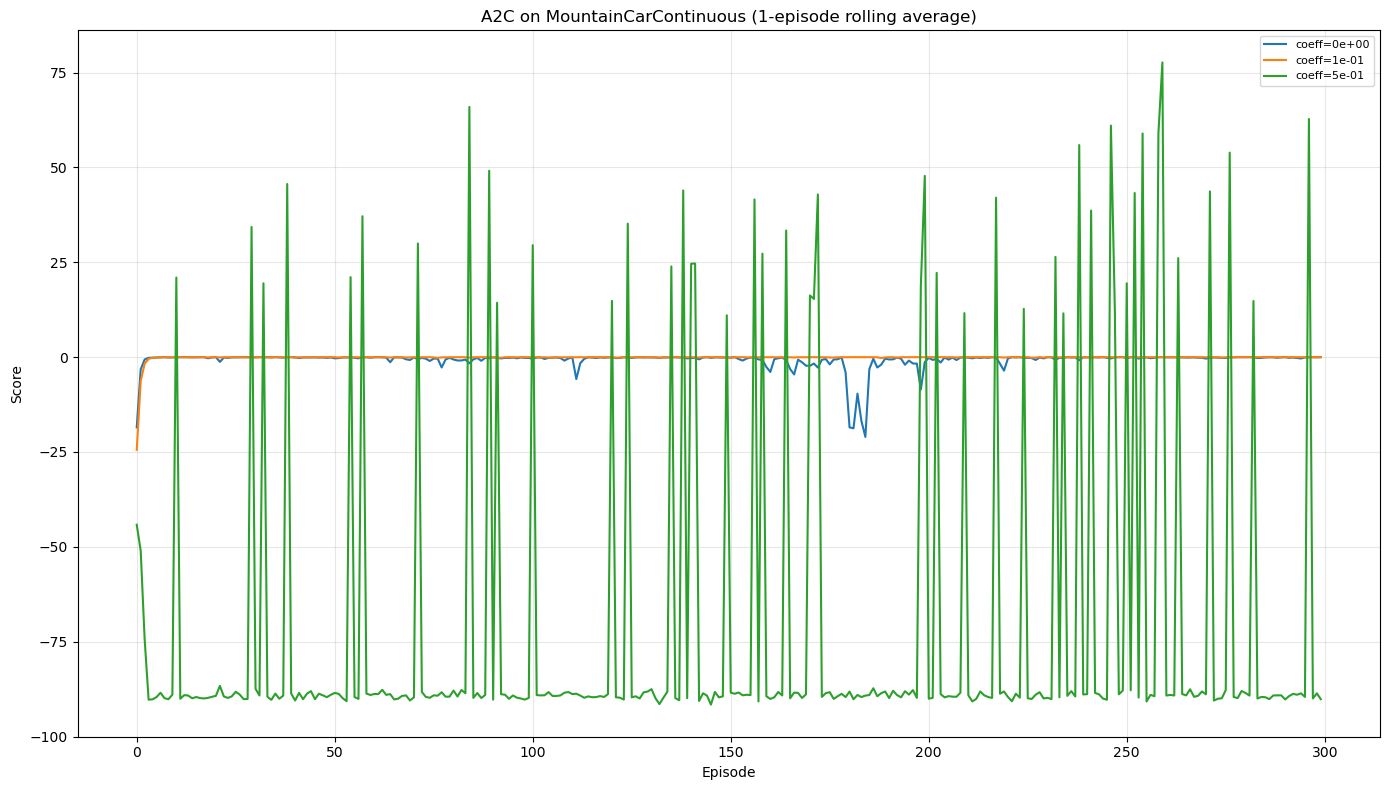

In [ ]:
### Visualizing the raw returns from the A2C
plot_all_coef(results, window=1, filename='coeff_comparison_a2c.png')

- > Higher entropy penalizes the agent more when it drives the std to zero which basically means is found doing nothing the optimal policy and forces it to explore more which leads to discovering the end goal at some episodes.
- > We cannot keep increasing the entropy as it causes the agent to over explore even getting to the end of the training which can cause instability in the training. 
- Also compared to the performance of the REINFORCE, the `A2C` has a better performance even with `0` entropy.

- For this reason we explore other options to improve the performance of the A2C


#### Exploration Failure and the Zero-Reward Trap

Standard on-policy A2C gets stuck at an average reward of exactly zero due to premature policy variance collapse induced by the sparse, harsh reward landscape of `MountainCarContinuous-v0`. To officially solve this environment, an agent must achieve an average reward of **+90.0 or higher over 100 consecutive trials**.

Because the car's engine is structurally too weak to climb directly to the goal, it must first drive away from the target to build momentum. Under unstructured exploration, any movement attempts initially incur small negative fuel penalties without reaching the goal. The critic network quickly determines that doing nothing (i.e., outputting a zero action) is optimal for short-term survival. Consequently, the actor progressively shrinks its exploration variance ($\sigma \rightarrow 0$), eventually eliminating exploration and becoming trapped at a flat reward of around **0.0**.

Similar behavior is also observed in Stable-Baselines3 A2C when `use_sde=False`, whereas enabling `use_sde=True` improves exploration and helps the agent to reach the goal.
To address this problem, we adopted generalized State-Dependent Exploration (gSDE), specifically the `n-step` variant, which resamples the exploration parameters every 
`n steps` and uses learned policy features to generate structured noise. This produces smoother and more temporally consistent exploration than independent Gaussian action noise, while preserving the original reward formulation. `Reward shaping` can also be used to address this problem where either `position or velocity` incentives are given to the agent.
Further details on the `gSDE` and the mathematical expressions can be found in this paper https://arxiv.org/pdf/2005.05719 


To address the zero-reward trap, we adopt **generalized State-Dependent Exploration (gSDE)**, specifically the **\(n\)-step variant**. In our implementation, the actor produces a state-dependent mean $\mu(s)$ and standard deviation $\sigma(s)$ from learned latent features, and the action is then sampled as $ a_t^{\text{raw}} = \mu(s_t) + \sigma(s_t) \odot \epsilon$, where $\epsilon \text{~} N(0, 1)$
followed by a tanh squashing function. The same exploration noise vector $\epsilon$ is reused for $n$ consecutive steps before being resampled, producing smoother and more temporally coherent exploration than independent Gaussian noise.

This structured exploration strategy helps the A2C agent maintain momentum long enough to discover successful trajectories in `MountainCarContinuous-v0`, preventing premature exploration collapse and avoiding convergence to the near-zero reward regime as shown in our simulation results.

#### Implementing the Agent Class with gSDE

In [23]:

class ActorNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims, n_actions):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.mu = nn.Linear(fc2_dims, n_actions)

        # SDE exploration weights: map state features to exploration noise scale
        self.log_std = nn.Linear(fc2_dims, n_actions)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        mu = self.mu(x)

        log_std = self.log_std(x)
        log_std = T.clamp(log_std, -20, 2)
        std = T.exp(log_std)
        return mu, std

class CriticNetwork(nn.Module):
    def __init__(self, lr, input_dims, fc1_dims, fc2_dims):
        super().__init__()
        self.fc1 = nn.Linear(*input_dims, fc1_dims)
        self.fc2 = nn.Linear(fc1_dims, fc2_dims)
        self.v = nn.Linear(fc2_dims, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def forward(self, state):
        if not isinstance(state, T.Tensor):
            state = T.tensor(np.array(state), dtype=T.float32)
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        value = self.v(x)
        return value

class RolloutBuffer:
    def __init__(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def store(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.states, self.actions, self.log_probs, self.rewards, self.dones, self.values = [], [], [], [], [], []



In [25]:
class Agent:
    def __init__(self, lr_actor, lr_critic, input_dims, n_actions,
                 gamma=0.99, gae_lambda=0.95, entropy_coeff=0.5,
                 layer1_size=256, layer2_size=256, min_entropy_coeff=0.01, entropy_decay=0.995):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coeff = entropy_coeff
        self.n_actions = n_actions
        self.initial_entropy_coeff = entropy_coeff
        self.min_entropy_coeff = min_entropy_coeff
        self.entropy_decay = entropy_decay

        self.actor = ActorNetwork(lr_actor, input_dims, layer1_size, layer2_size, n_actions)
        self.critic = CriticNetwork(lr_critic, input_dims, layer1_size, layer2_size)
        self.memory = RolloutBuffer()

        # Persistent noise matrix for state-dependent exploration (gSDE)
        self.exploration_noise = None
        self.reset_noise()

    def reset_noise(self):
        """Samples a fresh persistent matrix for structured exploration."""
        # For simplicity in 1D action space, sample standard normal scalar/vector
        self.exploration_noise = T.randn(self.n_actions)

    def decay_entropy(self):
        self.entropy_coeff = max(
            self.min_entropy_coeff,
            self.entropy_coeff * self.entropy_decay
        )

    def choose_action(self, observation):
        state = T.tensor(np.array(observation), dtype=T.float32)

        mu, std = self.actor(state)

        # State-Dependent Exploration core logic:
        # Action noise is scaled by the variance but consistent across timesteps
        raw_action = mu + std * self.exploration_noise

        # Enforce action space bounds cleanly using Tanh
        action = T.tanh(raw_action)

        # Analytical log probability adjustment for Tanh squashing
        # log_prob(tanh(x)) = log_prob_normal(x) - log(1 - tanh(x)^2)
        dist = T.distributions.Normal(mu, std)
        raw_log_prob = dist.log_prob(raw_action).sum()
        log_prob = raw_log_prob - T.log(1.0 - action.pow(2) + 1e-8).sum()

        value = self.critic(state).squeeze(-1)

        return action.detach().numpy(), log_prob, value

    def store_transition(self, state, action, log_prob, reward, done, value):
        self.memory.store(state, action, log_prob, reward, done, value)


    def compute_returns_advantages(self, last_state, done):
        last_state = T.tensor(np.array(last_state), dtype=T.float32)
        next_value = 0.0 if done else self.critic(last_state).item()

        rewards = self.memory.rewards
        dones = self.memory.dones
        values = [v.item() for v in self.memory.values]

        returns = []
        advantages = []

        gae = 0.0
        values = values + [next_value]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t + 1] * (1 - int(dones[t])) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - int(dones[t])) * gae
            advantages.insert(0, gae)
            returns.insert(0, gae + values[t])

        returns = T.tensor(returns, dtype=T.float32)
        advantages = T.tensor(advantages, dtype=T.float32)

        advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        return returns, advantages

    def learn(self, last_state, done):
        returns, advantages = self.compute_returns_advantages(last_state, done)

        states = T.tensor(np.array(self.memory.states), dtype=T.float32)
        actions = T.tensor(np.array(self.memory.actions), dtype=T.float32)

        mu, std = self.actor(states)
        dist = T.distributions.Normal(mu, std)

        # Invert Tanh back safely to find raw actions for calculating updated distributions
        raw_actions = T.atanh(T.clamp(actions, -0.999, 0.999))

        # Calculate updated logs with tanh Jacobian penalty
        log_probs = dist.log_prob(raw_actions).sum(dim=-1) - T.log(1.0 - actions.pow(2) + 1e-6).sum(dim=-1)
        entropy = dist.entropy().sum(dim=-1).mean()

        critic_values = self.critic(states).squeeze(-1)

        actor_loss = -(log_probs * advantages.detach()).mean()
        critic_loss = F.mse_loss(critic_values, returns)

        # Minimize total loss
        loss = actor_loss + 0.5 * critic_loss - self.entropy_coeff * entropy

        self.actor.optimizer.zero_grad()
        self.critic.optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent policy explosion during momentum discoveries
        T.nn.utils.clip_grad_norm_(self.actor.parameters(), max_norm=0.5)
        T.nn.utils.clip_grad_norm_(self.critic.parameters(), max_norm=0.5)

        self.actor.optimizer.step()
        self.critic.optimizer.step()

        self.memory.clear()

### Defining Helper functions for traning and visualizatiion

In [ ]:
def train_agent(lr_actor, lr_critic, gamma, num_episodes=200, n_steps=20, layer1_size=256, layer2_size=256, coeff=0.05, seed=42):
    env = gym.make('MountainCarContinuous-v0', render_mode='human')

    agent = Agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        input_dims=[2],
        n_actions=1,
        gamma=gamma,
        entropy_coeff=coeff, # Notice: higher entropy coeff (e.g., 0.05) keeps distribution broad
        layer1_size=layer1_size,
        layer2_size=layer2_size
    )

    score_history = []

    T.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    for episode in range(num_episodes):
        observation, info = env.reset(seed=seed + episode)
        done = False
        score = 0
        step_count = 0

        # Reset exploration direction choice at start of each trajectory run
        # agent.reset_noise()

        while not done:
            action, log_prob, value = agent.choose_action(observation)

            action = np.array(action, dtype=np.float32).reshape((1,))
            observation_, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store_transition(
                state=observation,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value
            )

            score += reward
            step_count += 1
            observation = observation_

            # Standard gSDE configuration: sample fresh noise vector every 4 steps
            if step_count % 50 == 0:
                agent.reset_noise()

            if step_count % n_steps == 0:
                agent.learn(observation, done)

        # agent.decay_entropy()
        score_history.append(score)
        print(f'gamma={gamma:.2f} | episode: {episode + 1}/{num_episodes} | score: {score:.2f} | entropy_coeff: {agent.entropy_coeff:.4f}')

    env.close()
    return score_history

def save_results(results, filename='training_logs.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
    print(f'Training logs saved to {filename}')


def plot_all(results, window=10, filename='gamma_comparison_a2c.png'):
    plt.figure(figsize=(12, 6))

    for gamma, scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        plt.plot(running_avg, label=f'γ = {gamma}')

    plt.title(f'A2C on MountainCarContinuous — {window}-episode rolling average')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=300)
    plt.show()


def moving_average(x, window=10):
    return np.convolve(x, np.ones(window)/window, mode='valid')


Training with gamma = 0.99


/home/einsbert/anaconda3/envs/torch_drl/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


gamma=0.99 | episode: 1/300 | score: 70.83 | entropy_coeff: 0.0100
gamma=0.99 | episode: 2/300 | score: 87.14 | entropy_coeff: 0.0100
gamma=0.99 | episode: 3/300 | score: 61.42 | entropy_coeff: 0.0100
gamma=0.99 | episode: 4/300 | score: 70.10 | entropy_coeff: 0.0100
gamma=0.99 | episode: 5/300 | score: 81.85 | entropy_coeff: 0.0100
gamma=0.99 | episode: 6/300 | score: 86.55 | entropy_coeff: 0.0100
gamma=0.99 | episode: 7/300 | score: 82.99 | entropy_coeff: 0.0100
gamma=0.99 | episode: 8/300 | score: 90.48 | entropy_coeff: 0.0100
gamma=0.99 | episode: 9/300 | score: 89.76 | entropy_coeff: 0.0100
gamma=0.99 | episode: 10/300 | score: 68.16 | entropy_coeff: 0.0100
gamma=0.99 | episode: 11/300 | score: 81.08 | entropy_coeff: 0.0100
gamma=0.99 | episode: 12/300 | score: 51.74 | entropy_coeff: 0.0100
gamma=0.99 | episode: 13/300 | score: 80.00 | entropy_coeff: 0.0100
gamma=0.99 | episode: 14/300 | score: 80.40 | entropy_coeff: 0.0100
gamma=0.99 | episode: 15/300 | score: 88.24 | entropy_coe

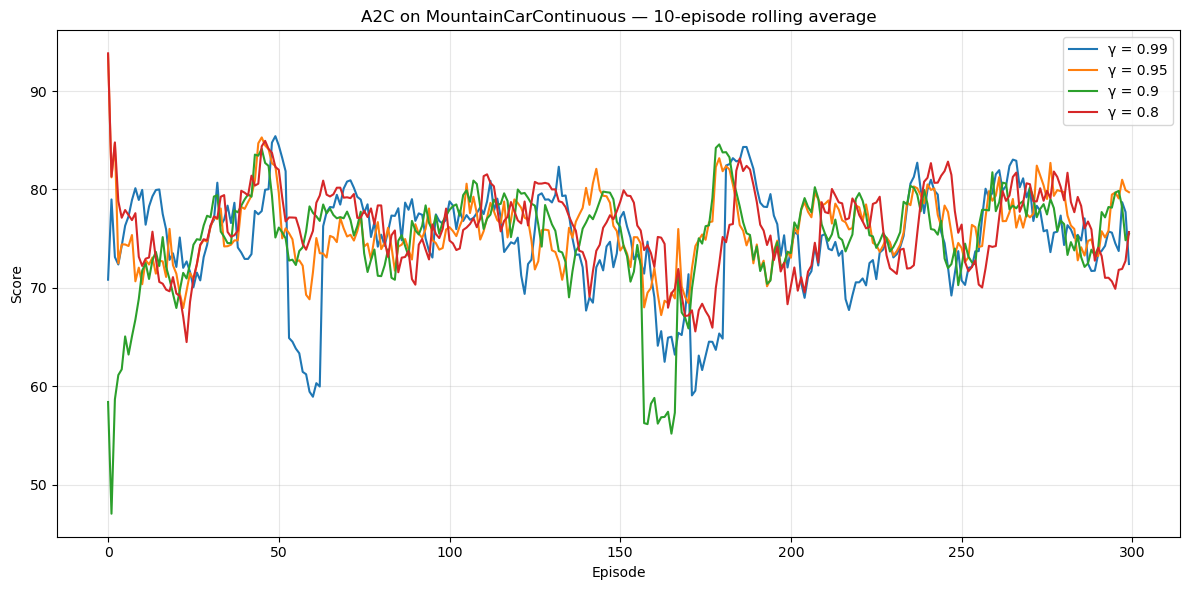

In [6]:
### Main training loop with different gamma values

gammas = [0.99, 0.95, 0.90, 0.80]#, 0.70, 0.50, 0.30, 0.10]
num_episodes = 300
lr_actor = 0.0001
lr_critic = 0.0001
n_steps = 10

results = {}

for gamma in gammas:
    print(f'\n{"=" * 50}')
    print(f'Training with gamma = {gamma}')
    print(f'{"=" * 50}')
    results[gamma] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

save_results(results, filename='training_logs_gammas.pkl')
plot_all(results, window=10, filename='gamma_comparison_a2c.png')

> The results demonstrate the significant impact of the discount factor on training stability and convergence behavior in A2C. 
- `γ=0.95` is used in the subsequent training since it generally gives a good performance

#### LEANRING RATE ANALYSIS OF A2C On MOUNTAINCAR-CONTINUOUS    


In [ ]:
### Training loop with different order of magnitude of actor and critic learning rates

def plot_all_lr(results, window=10, filename='lr_comparison_a2c.png'):
    """
    results: dict of {(lr_actor, lr_critic): score_history_list}
    """
    plt.figure(figsize=(10, 6))

    for (lr_actor, lr_critic), scores in results.items():
        scores = np.array(scores, dtype=np.float32)
        running_avg = np.zeros(len(scores))

        for t in range(len(scores)):
            running_avg[t] = np.mean(scores[max(0, t - window + 1): t + 1])

        label = f"actor={lr_actor:.0e}, critic={lr_critic:.0e}"
        plt.plot(running_avg, label=label)

    plt.title(f'A2C on MountainCarContinuous ({window}-episode rolling average)')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend(loc='best', fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(filename, dpi=600)
    print(f'Plot saved to {filename}')

In [ ]:
gamma = 0.95
num_episodes = 100
n_steps = 10

# lr_combinations = [
#     (0.000001,  0.000001),
#     (0.00001,  0.00001),
#     (0.0001,   0.0001),
#     (0.001, 0.001),
#     (0.01, 0.01)
# ]

lr_combinations = [
    (0.00001,  0.000005),
    (0.00005,  0.0001),
    (0.0001,   0.00005),
    (0.00001,  0.00001),
    (0.0001,   0.0001),
    (0.001, 0.001),
]

results = {}

for lr_actor, lr_critic in lr_combinations:
    label = f"actor={lr_actor:.0e}, critic={lr_critic:.0e}"
    print(f'\n{"=" * 50}')
    print(f'Training with {label}')
    print(f'{"=" * 50}')

    results[(lr_actor, lr_critic)] = train_agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        num_episodes=num_episodes,
        n_steps=n_steps,
        layer1_size=256,
        layer2_size=256,
        coeff=0.01
    )

# save_results(results, filename='training_logs_lr.pkl')
# plot_all_lr(results, window=10, filename='lr_comparison_a2c.png')


Training with actor=1e-05, critic=5e-06
gamma=0.95 | episode: 1/100 | score: 78.93 | entropy_coeff: 0.0100
gamma=0.95 | episode: 2/100 | score: 39.88 | entropy_coeff: 0.0100
gamma=0.95 | episode: 3/100 | score: 82.11 | entropy_coeff: 0.0100
gamma=0.95 | episode: 4/100 | score: 74.56 | entropy_coeff: 0.0100
gamma=0.95 | episode: 5/100 | score: 73.60 | entropy_coeff: 0.0100
gamma=0.95 | episode: 6/100 | score: 83.54 | entropy_coeff: 0.0100
gamma=0.95 | episode: 7/100 | score: 16.64 | entropy_coeff: 0.0100
gamma=0.95 | episode: 8/100 | score: 80.51 | entropy_coeff: 0.0100
gamma=0.95 | episode: 9/100 | score: 87.59 | entropy_coeff: 0.0100
gamma=0.95 | episode: 10/100 | score: 87.10 | entropy_coeff: 0.0100
gamma=0.95 | episode: 11/100 | score: 42.98 | entropy_coeff: 0.0100
gamma=0.95 | episode: 12/100 | score: 65.08 | entropy_coeff: 0.0100
gamma=0.95 | episode: 13/100 | score: 92.17 | entropy_coeff: 0.0100
gamma=0.95 | episode: 14/100 | score: 72.80 | entropy_coeff: 0.0100
gamma=0.95 | epi

Training logs saved to training_logs_lr.pkl
Plot saved to lr_comparison_a2c.png


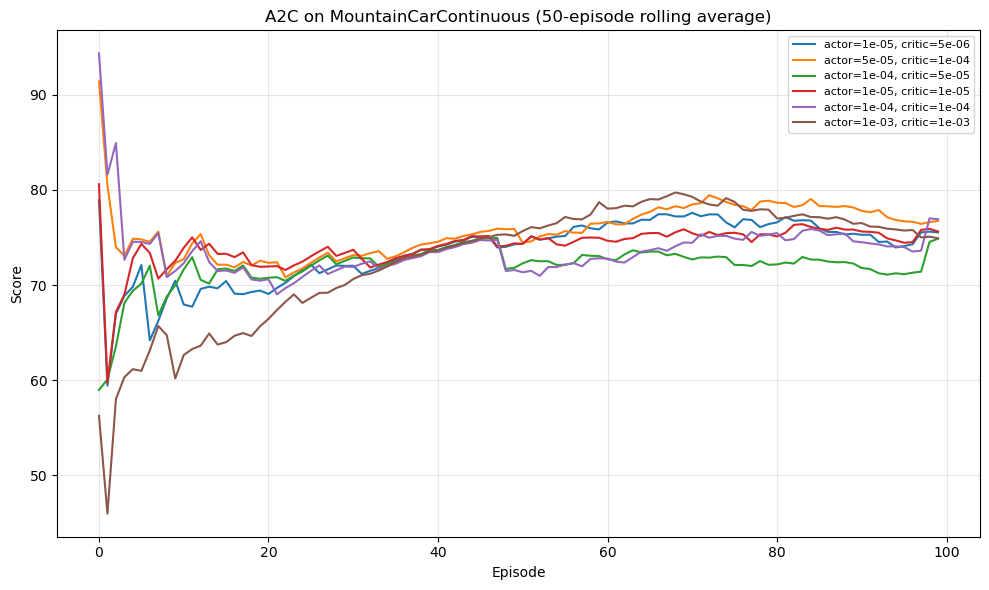

In [ ]:
save_results(results, filename='training_logs_lr.pkl')
plot_all_lr(results, window=50, filename='lr_comparison_a2c.png')

**General observations**
-  `A=5e-05, C=1e-04` and `A=1e-03, C=1e-03` generally works well. They offer the best combination of stable convergence, low variance in the late training phase, and consistently high final score.
- `A=5e-05, C=1e-04` is used in the final training.

#### Final training of the A2C using the best parameter configurations that we have observed so far. 
- `γ=0.95`
- entropy coefficient is decayed from `0.2` to `0.01`
- actor and critic learning rates: `A=5e-05, C=1e-04` 
- For the `n-step` `gsde` adopted, at the step frequency becomes too large, the performance approaches the A2C without the `gsde` implementation. `50` was used in our simulation

In [26]:
def train_agent(lr_actor, lr_critic, gamma, num_episodes=200, n_steps=20, layer1_size=256, layer2_size=256, coeff=0.05, seed=42):
    env = gym.make('MountainCarContinuous-v0', render_mode='human')

    agent = Agent(
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        input_dims=[2],
        n_actions=1,
        gamma=gamma,
        entropy_coeff=coeff, # Notice: higher entropy coeff (e.g., 0.05) keeps distribution broad
        layer1_size=layer1_size,
        layer2_size=layer2_size
    )

    score_history = []

    T.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    for episode in range(num_episodes):
        observation, info = env.reset(seed=seed + episode)
        done = False
        score = 0
        step_count = 0

        # Reset exploration direction choice at start of each trajectory run
        # agent.reset_noise()

        while not done:
            action, log_prob, value = agent.choose_action(observation)

            action = np.array(action, dtype=np.float32).reshape((1,))
            observation_, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.store_transition(
                state=observation,
                action=action,
                log_prob=log_prob,
                reward=reward,
                done=done,
                value=value
            )

            score += reward
            step_count += 1
            observation = observation_

            # Standard gSDE configuration: sample fresh noise vector every 4 steps
            if step_count % 50 == 0:
                agent.reset_noise()

            if step_count % n_steps == 0:
                agent.learn(observation, done)

        agent.decay_entropy()
        score_history.append(score)
        print(f'gamma={gamma:.2f} | episode: {episode + 1}/{num_episodes} | score: {score:.2f} | entropy_coeff: {agent.entropy_coeff:.4f}')

    env.close()
    return score_history


Training A2C with fixed hyperparameters:
  gamma=0.95, lr_actor=5e-05, lr_critic=1e-04, coeff=0.2
gamma=0.95 | episode: 1/250 | score: 83.20 | entropy_coeff: 0.1990
gamma=0.95 | episode: 2/250 | score: 42.96 | entropy_coeff: 0.1980
gamma=0.95 | episode: 3/250 | score: 88.47 | entropy_coeff: 0.1970
gamma=0.95 | episode: 4/250 | score: 73.67 | entropy_coeff: 0.1960
gamma=0.95 | episode: 5/250 | score: 73.93 | entropy_coeff: 0.1950
gamma=0.95 | episode: 6/250 | score: 82.92 | entropy_coeff: 0.1941
gamma=0.95 | episode: 7/250 | score: 32.34 | entropy_coeff: 0.1931
gamma=0.95 | episode: 8/250 | score: 84.25 | entropy_coeff: 0.1921
gamma=0.95 | episode: 9/250 | score: 80.51 | entropy_coeff: 0.1912
gamma=0.95 | episode: 10/250 | score: 88.19 | entropy_coeff: 0.1902
gamma=0.95 | episode: 11/250 | score: 87.10 | entropy_coeff: 0.1893
gamma=0.95 | episode: 12/250 | score: 58.41 | entropy_coeff: 0.1883
gamma=0.95 | episode: 13/250 | score: 78.24 | entropy_coeff: 0.1874
gamma=0.95 | episode: 14/25

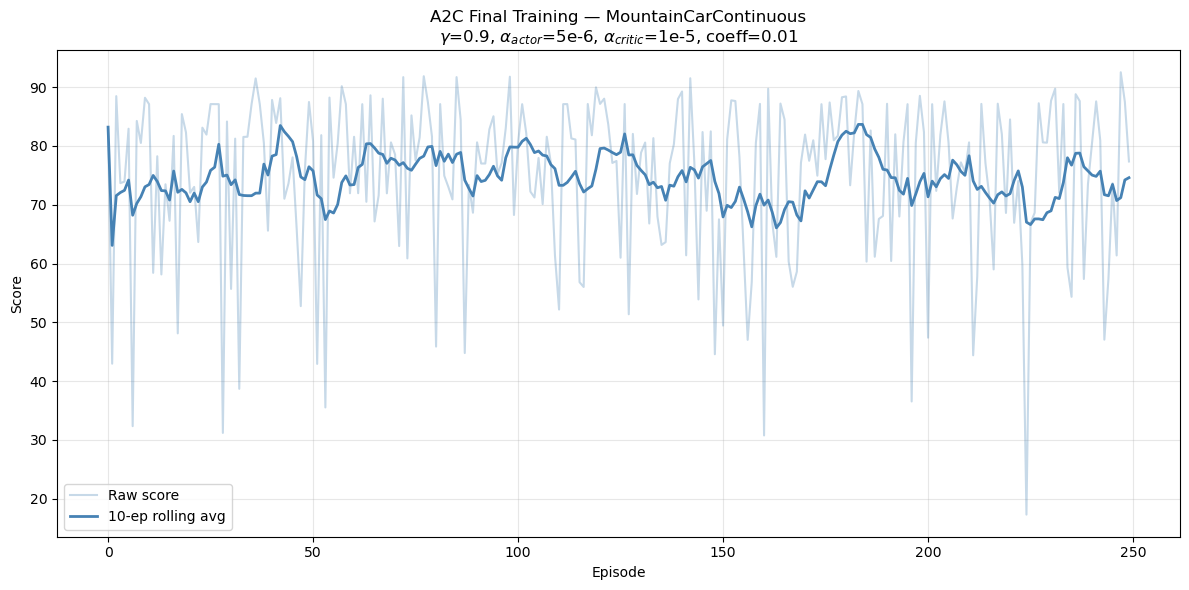

In [29]:
gamma = 0.95
lr_actor = 5e-5
lr_critic = 1e-4
coeff = 0.2
num_episodes = 250
n_steps = 10

print(f'Training A2C with fixed hyperparameters:')
print(f'  gamma={gamma}, lr_actor={lr_actor:.0e}, lr_critic={lr_critic:.0e}, coeff={coeff}')
print(f'{"=" * 50}')

score_history = train_agent(
    lr_actor=lr_actor,
    lr_critic=lr_critic,
    gamma=gamma,
    num_episodes=num_episodes,
    n_steps=n_steps,
    layer1_size=256,
    layer2_size=256,
    coeff=coeff
)

save_results({'final': score_history}, filename='training_logs_final.pkl')

# Plot
scores = np.array(score_history, dtype=np.float32)
window = 10
running_avg = np.array([np.mean(scores[max(0, t - window + 1): t + 1]) for t in range(len(scores))])

plt.figure(figsize=(12, 6))
plt.plot(scores, alpha=0.3, color='steelblue', label='Raw score')
plt.plot(running_avg, color='steelblue', linewidth=2, label=f'{window}-ep rolling avg')
plt.title('A2C Final Training — MountainCarContinuous\n'
          r'$\gamma$=0.9, $\alpha_{actor}$=5e-6, $\alpha_{critic}$=1e-5, coeff=0.01')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('final_training_a2c.png', dpi=300)
plt.show()